#Importing Required Modules

In [ ]:
import pandas as pd
import numpy as np
import re
import nltk
nltk.download('stopwords')
nltk.download('wordnet')
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from scipy.sparse import hstack
from sklearn.metrics import classification_report
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
import lightgbm as lgb
import matplotlib.pyplot as plt

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


#Let's connect to my google drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


#Data loaing & Analyzing

In [ ]:
df=pd.read_csv('/content/drive/MyDrive/Airlines/Airline_review.csv')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23171 entries, 0 to 23170
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Unnamed: 0              23171 non-null  int64  
 1   Airline Name            23171 non-null  object 
 2   Overall_Rating          23171 non-null  object 
 3   Review_Title            23171 non-null  object 
 4   Review Date             23171 non-null  object 
 5   Verified                23171 non-null  bool   
 6   Review                  23171 non-null  object 
 7   Aircraft                7129 non-null   object 
 8   Type Of Traveller       19433 non-null  object 
 9   Seat Type               22075 non-null  object 
 10  Route                   19343 non-null  object 
 11  Date Flown              19417 non-null  object 
 12  Seat Comfort            19016 non-null  float64
 13  Cabin Staff Service     18911 non-null  float64
 14  Food & Beverages        14500 non-null

In [ ]:
df.head()

,Unnamed: 0,Airline Name,Overall_Rating,Review_Title,Review Date,Verified,Review,Aircraft,Type Of Traveller,Seat Type,Route,Date Flown,Seat Comfort,Cabin Staff Service,Food & Beverages,Ground Service,Inflight Entertainment,Wifi & Connectivity,Value For Money,Recommended
0,0,AB Aviation,9,"""pretty decent airline""",11th November 2019,True,Moroni to Moheli. Turned out to be a pretty ...,NaN,Solo Leisure,Economy Class,Moroni to Moheli,November 2019,4.0,5.0,4.0,4.0,NaN,NaN,3.0,yes
1,1,AB Aviation,1,"""Not a good airline""",25th June 2019,True,Moroni to Anjouan. It is a very small airline...,E120,Solo Leisure,Economy Class,Moroni to Anjouan,June 2019,2.0,2.0,1.0,1.0,NaN,NaN,2.0,no
2,2,AB Aviation,1,"""flight was fortunately short""",25th June 2019,True,Anjouan to Dzaoudzi. A very small airline an...,Embraer E120,Solo Leisure,Economy Class,Anjouan to Dzaoudzi,June 2019,2.0,1.0,1.0,1.0,NaN,NaN,2.0,no
3,3,Adria Airways,1,"""I will never fly again with Adria""",28th September 2019,False,Please do a favor yourself and do not fly wi...,NaN,Solo Leisure,Economy Class,Frankfurt to Pristina,September 2019,1.0,1.0,NaN,1.0,NaN,NaN,1.0,no
4,4,Adria Airways,1,"""it ruined our last days of holidays""",24th September 2019,True,Do not book a flight with this airline! My fr...,NaN,Couple Leisure,Economy Class,Sofia to Amsterdam via Ljubljana,September 2019,1.0,1.0,1.0,1.0,1.0,1.0,1.0,no


In [ ]:
df.columns

Index(['Unnamed: 0', 'Airline Name', 'Overall_Rating', 'Review_Title',
       'Review Date', 'Verified', 'Review', 'Aircraft', 'Type Of Traveller',
       'Seat Type', 'Route', 'Date Flown', 'Seat Comfort',
       'Cabin Staff Service', 'Food & Beverages', 'Ground Service',
       'Inflight Entertainment', 'Wifi & Connectivity', 'Value For Money',
       'Recommended'],
      dtype='object')

## Drop unnecessary columns and standardize
## Drop rows where critical data is missing
## Convert Rating to integer for loyalty classification

In [ ]:
df=df.drop(columns=[col for col in df.columns if col.startswith('[source') or col.startswith('Unnamed:')])
df=df.rename(columns={'Overall_Rating':'Rating'})

df=df.dropna(subset=['Review','Rating','Review Date','Recommended'])

df['Rating']=pd.to_numeric(df['Rating'],errors='coerce').fillna(0).astype(int)
df['Recommended_Target']=df['Recommended'].map({'yes':1,'no':0})

In [ ]:
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))
def clean_text(text):
    text=text.lower()
    text=re.sub(r'[^\w\s]',' ',text)
    text=re.sub(r'\s+[a-zA-Z]\s+',' ',text)
    words=text.split()
    words=[lemmatizer.lemmatize(word) for word in words if word not in stop_words]
    return ' '.join(words)

df['Clean_Review'] = df['Review'].apply(clean_text)

#WLI KPI CALCULATION SETUP
## Define columns for WLI components
## Proxy for Sentiment_Depth (emotional interaction metrics, max score 5)
## Clean and standardize service ratings (fill NaNs and ensure numeric type)

In [ ]:
service_rating_cols=['Seat Comfort','Cabin Staff Service','Food & Beverages','Ground Service','Inflight Entertainment','Wifi & Connectivity','Value For Money']
sentiment_depth_cols=['Cabin Staff Service','Inflight Entertainment']

for col in service_rating_cols:
    df[col]=pd.to_numeric(df[col],errors='coerce').fillna(0).astype(int)

#HYBRID FEATURE ENGINEERING

In [ ]:
tfidf=TfidfVectorizer(ngram_range=(1,2),max_features=5000)
X_text=tfidf.fit_transform(df['Clean_Review'])

categorical_cols=['Type Of Traveller', 'Seat Type', 'Airline Name']
df[categorical_cols]=df[categorical_cols].fillna('Unknown_Cat')
encoder=OneHotEncoder(handle_unknown='ignore',sparse_output=True)
X_structured=encoder.fit_transform(df[categorical_cols])

X_numerical=df[service_rating_cols].values

X_hybrid_sparse=hstack([X_text,X_structured])
X_hybrid_dense=np.hstack([X_hybrid_sparse.toarray(),X_numerical])
y=df['Recommended_Target']

feature_names_text=tfidf.get_feature_names_out()
feature_names_structured=encoder.get_feature_names_out(categorical_cols)
all_feature_names=np.concatenate([feature_names_text,feature_names_structured,service_rating_cols])

#MODEL TRAINING
##Model 1: LIGHTGBM

In [ ]:
X_train,X_test,y_train,y_test=train_test_split(X_hybrid_dense,y,test_size=0.2,random_state=42,stratify=y)

lgbm_model=lgb.LGBMClassifier(n_estimators=500,learning_rate=0.05,max_depth=7,random_state=42,verbose=-1)

print("Training LightGBM Model to Derive WLI Weights")
lgbm_model.fit(X_train,y_train)

Training LightGBM Model to Derive WLI Weights


LGBMClassifier(learning_rate=0.05, max_depth=7, n_estimators=500,
               random_state=42, verbose=-1)

## Classification report for LightGBM model

In [ ]:
y_pred_lgbm = lgbm_model.predict(X_test)
print("--- LightGBM Classification Report ---")
print(classification_report(y_test, y_pred_lgbm))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


--- LightGBM Classification Report ---
              precision    recall  f1-score   support

           0       0.97      0.97      0.97      3073
           1       0.94      0.94      0.94      1562

    accuracy                           0.96      4635
   macro avg       0.95      0.95      0.95      4635
weighted avg       0.96      0.96      0.96      4635



##Model 2: LogisticRegression

In [ ]:
print("\n--- Training Logistic Regression Model ---")
lr_model = LogisticRegression(random_state=42, solver='liblinear')
lr_model.fit(X_train, y_train)



--- Training Logistic Regression Model ---


LogisticRegression(random_state=42, solver='liblinear')

##Classification report for Logistic Regression model

In [ ]:
y_pred_lr = lr_model.predict(X_test)
print("\n--- Logistic Regression Classification Report ---")
print(classification_report(y_test, y_pred_lr))


--- Logistic Regression Classification Report ---
              precision    recall  f1-score   support

           0       0.96      0.97      0.96      3073
           1       0.93      0.93      0.93      1562

    accuracy                           0.95      4635
   macro avg       0.95      0.95      0.95      4635
weighted avg       0.95      0.95      0.95      4635



##Model 3: XGBOOST

In [ ]:
print("\n--- Training XGBoost Model ---")
xgb_model = XGBClassifier(random_state=42)
xgb_model.fit(X_train, y_train)



--- Training XGBoost Model ---


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

##Classification report for XGBOOST model

In [ ]:
y_pred_xgb = xgb_model.predict(X_test)
print("\n--- XGBoost Classification Report ---")
print(classification_report(y_test, y_pred_xgb))


--- XGBoost Classification Report ---
              precision    recall  f1-score   support

           0       0.97      0.97      0.97      3073
           1       0.94      0.93      0.93      1562

    accuracy                           0.96      4635
   macro avg       0.95      0.95      0.95      4635
weighted avg       0.96      0.96      0.96      4635



#DERIVE WLI WEIGHTS FOR SERVICE_ACTIONABILITY
##The model's feature importance is used as the 'W_j' weights for the Service_Actionability component

In [ ]:
feature_importance_series=pd.Series(lgbm_model.feature_importances_,index=all_feature_names)
service_importance=feature_importance_series[service_rating_cols].sum()
normalized_service_weights={k: v/service_importance for k, v in feature_importance_series[service_rating_cols].to_dict().items()}

#Let's CALCULATE WEIGHTED LOYALTY INDEX (WLI)
# Define the three conceptual weights
# Using Max possible score for normalization


In [ ]:
W1_NPS=1/3
W2_SENTIMENT=1/3
W3_SERVICE=1/3
def calculate_wli_conceptual(row,service_weights):
    NPS_Core=row['Rating']/10     #NPS_Core (W1)
    Sentiment_Depth=row[sentiment_depth_cols].mean()/5     #Sentiment_Depth (W2)
    weighted_sum=sum(row[col]*service_weights[col] for col in service_weights.keys())     #Service_Actionability (W3):

    max_rating=5
    max_possible_wli=sum(max_rating*service_weights[col] for col in service_weights.keys())
    Service_Actionability=weighted_sum/max_possible_wli

    wli_score=(W1_NPS*NPS_Core)+(W2_SENTIMENT*Sentiment_Depth)+(W3_SERVICE*Service_Actionability)
    return wli_score*100

df['WLI_i']=df.apply(lambda row: calculate_wli_conceptual(row,normalized_service_weights),axis=1)

final_wli_kpi=df['WLI_i'].mean()

print(f"PRIMARY KPI: Weighted Loyalty Index (WLI)")
print(f"Weights used: W1 (NPS Core) = {W1_NPS:.2f}, W2 (Sentiment Depth) = {W2_SENTIMENT:.2f}, W3 (Service Actionability) = {W3_SERVICE:.2f}")
print(f"Overall Airline WLI Score: {final_wli_kpi:.2f} (Index out of 100)")

PRIMARY KPI: Weighted Loyalty Index (WLI)
Weights used: W1 (NPS Core) = 0.33, W2 (Sentiment Depth) = 0.33, W3 (Service Actionability) = 0.33
Overall Airline WLI Score: 35.00 (Index out of 100)


#TIME SERIES ANALYSIS (WLI Trend Task)

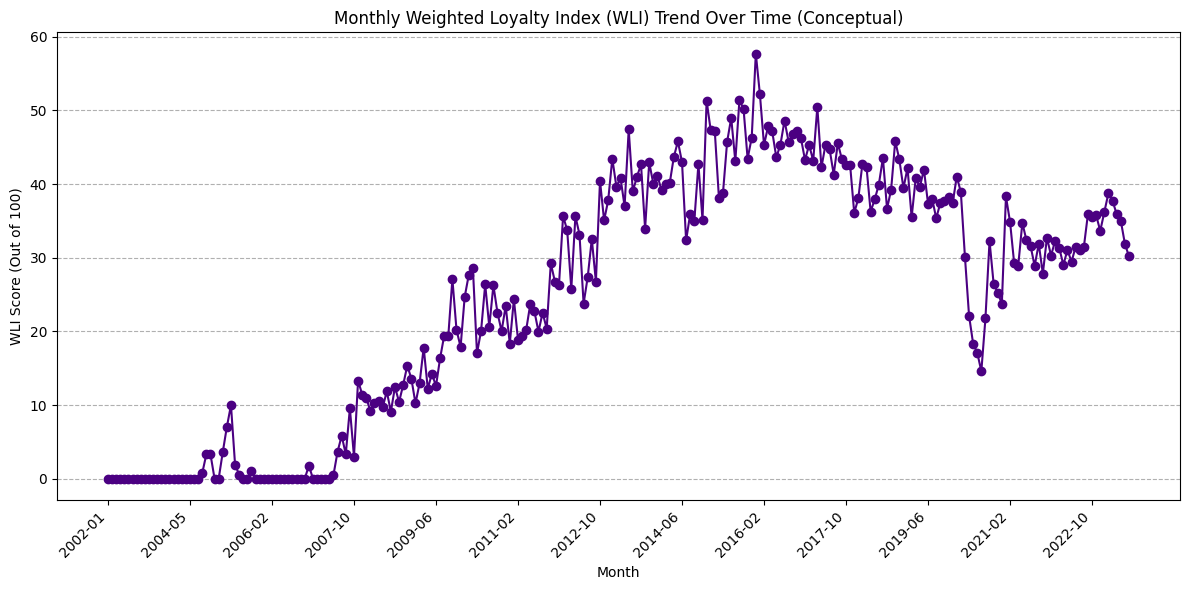

In [ ]:
df_temporal=df.copy()
df_temporal['Review Date']=pd.to_datetime(df_temporal['Review Date'],errors='coerce')
df_temporal=df_temporal.dropna(subset=['Review Date'])
df_temporal['YearMonth']=df_temporal['Review Date'].dt.to_period('M')

monthly_data=df_temporal.groupby('YearMonth')['WLI_i'].mean().reset_index()
monthly_data['Time']=monthly_data['YearMonth'].astype(str)

plt.figure(figsize=(12,6))
plt.plot(monthly_data['Time'],monthly_data['WLI_i'],marker='o',linestyle='-',color='indigo')
plt.title('Monthly Weighted Loyalty Index (WLI) Trend Over Time (Conceptual)')
plt.xlabel('Month')
plt.ylabel('WLI Score (Out of 100)')
n=max(1,len(monthly_data)//12)
plt.xticks(monthly_data['Time'][::n],rotation=45,ha='right')
plt.grid(axis='y',linestyle='--')
plt.tight_layout()
plt.show()

#FINAL INSIGHTS (Model Drivers)


In [ ]:
all_feature_names_non_numerical=np.concatenate([feature_names_text,feature_names_structured,service_rating_cols])
final_importance=pd.Series(lgbm_model.feature_importances_,index=all_feature_names_non_numerical)
top_predictors=final_importance.nlargest(20)

print(f"\n--- FINAL INSIGHTS: Top Predictors of Loyalty (LightGBM) ---")
print(f"Top 20 most important features (Text, Structured, & Numerical):\n{top_predictors.sort_values(ascending=False)}")


--- FINAL INSIGHTS: Top Predictors of Loyalty (LightGBM) ---
Top 20 most important features (Text, Structured, & Numerical):
Value For Money                  745
Ground Service                   470
Cabin Staff Service              435
Seat Comfort                     376
flight                           344
Food & Beverages                 254
good                             163
airline                          143
seat                             140
Seat Type_Unknown_Cat            128
friendly                         119
time                             116
Type Of Traveller_Unknown_Cat    115
hour                             101
service                          100
food                              91
Inflight Entertainment            87
cabin                             72
crew                              72
staff                             68
dtype: int32
